In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load data, skipping header rows
data = pd.read_csv(r"C:\Users\bares\OneDrive\FIN4820\12_Industry_Portfolios.CSV", header=0, skiprows=11)

# Function to check if a string can be converted to a number
def is_number(s):
    try:
        float(s)
        return True
    except ValueError:
        return False

# The first column is the date column
data.columns = ['Date'] + list(data.columns[1:])

# Filter out rows where the Date is not a number and remove NaN values
data = data[data['Date'].apply(is_number)]
data = data.dropna(subset=['Date'])

# Function to convert date to datetime
def convert_date(date_str):
    date_str = str(int(float(date_str)))  # Convert to integer and then to string
    if len(date_str) == 4:  # YYYY format
        return pd.to_datetime(date_str + '01', format='%Y%m')
    elif len(date_str) == 6:  # YYYYMM format
        return pd.to_datetime(date_str, format='%Y%m')
    else:
        return pd.NaT  # Not a Time

# Convert the date to datetime
data['Date'] = data['Date'].apply(convert_date)

# Remove any rows where date conversion failed
data = data.dropna(subset=['Date'])

# Set the Date column as the index and sort
data.set_index('Date', inplace=True)
data.sort_index(inplace=True)

# Convert percentage strings to float
for col in data.columns:
    data[col] = data[col].astype(str).str.strip().replace('-99.99', 'NaN').astype(float) / 100

# Split data into estimation and testing periods
cutoff_date = pd.Timestamp('1990-12-31')
estimation_data = data[data.index <= cutoff_date]
testing_data = data[data.index > cutoff_date]

# Calculate covariance matrix and expected returns for estimation period
cov_matrix = estimation_data.cov()
expected_returns = estimation_data.mean()

# Function to calculate tangency portfolio weights
def tangency_portfolio(expected_returns, cov_matrix, risk_free_rate=0):
    inv_cov = np.linalg.inv(cov_matrix)
    ones = np.ones(len(expected_returns))
    a = np.dot(inv_cov, expected_returns - risk_free_rate)
    b = np.dot(ones.T, a)
    weights = a / b
    return weights

# Calculate tangency portfolio weights
weights = tangency_portfolio(expected_returns, cov_matrix)

# Calculate portfolio returns
tangency_returns = (testing_data * weights).sum(axis=1)
equal_weight_returns = testing_data.mean(axis=1)

# Calculate Sharpe ratios
def sharpe_ratio(returns, risk_free_rate=0):
    excess_returns = returns - risk_free_rate
    return np.sqrt(12) * excess_returns.mean() / excess_returns.std()

tangency_sharpe = sharpe_ratio(tangency_returns)
equal_weight_sharpe = sharpe_ratio(equal_weight_returns)

# Summary statistics for monthly industry return data
summary_stats = data.describe().T
summary_stats['skew'] = data.skew()
summary_stats['kurtosis'] = data.kurtosis()

# Tangency portfolio weights summary
weights_summary = pd.Series(weights, index=data.columns).sort_values(ascending=False)

# Monthly returns of tangency portfolio
tangency_returns_summary = tangency_returns.describe()

# Sharpe ratio comparison
sharpe_comparison = pd.DataFrame({
    'Tangency Portfolio': [tangency_sharpe],
    'Equally Weighted Portfolio': [equal_weight_sharpe]
}, index=['Sharpe Ratio'])

# Visualizations

# 1. Tangency portfolio weights
plt.figure(figsize=(12, 6))
weights_summary.plot(kind='bar')
plt.title('Tangency Portfolio Weights')
plt.xlabel('Industry')
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('tangency_weights.png')
plt.close()

# 2. Monthly returns of tangency portfolio
plt.figure(figsize=(12, 6))
tangency_returns.plot()
plt.title('Monthly Returns of Tangency Portfolio')
plt.xlabel('Date')
plt.ylabel('Return')
plt.tight_layout()
plt.savefig('tangency_returns.png')
plt.close()

# Print results
print("Summary Statistics for Monthly Industry Returns:")
print(summary_stats)
print("\nTangency Portfolio Weights:")
print(weights_summary)
print("\nTangency Portfolio Monthly Returns Summary:")
print(tangency_returns_summary)
print("\nSharpe Ratio Comparison:")
print(sharpe_comparison)

# Save results to CSV files
summary_stats.to_csv('summary_stats.csv')
weights_summary.to_csv('tangency_weights.csv')
tangency_returns_summary.to_csv('tangency_returns_summary.csv')
sharpe_comparison.to_csv('sharpe_comparison.csv')

Summary Statistics for Monthly Industry Returns:
        count      mean        std     min       25%      50%       75%  \
NoDur  5104.0  5.150274  18.434548 -0.4368  0.007400  0.09735  1.530000   
Durbl  5104.0  3.204205  13.072761 -0.6330  0.005675  0.13770  1.188200   
Manuf  5104.0  3.796932  10.894298 -0.5761  0.009000  0.11660  2.860000   
Enrgy  5104.0  6.110077  20.476112 -0.5456  0.007375  0.14040  1.642250   
Chems  5104.0  5.675470  19.995702 -0.5238  0.006100  0.10720  1.170000   
BusEq  5104.0  6.295399  26.828375 -0.5134  0.005700  0.14115  2.623475   
Telcm  5104.0  9.535508  32.360394 -0.5678  0.007500  0.07000  1.332500   
Utils  5104.0  5.955561  22.671647 -0.4310  0.008600  0.09835  1.314325   
Shops  5104.0  4.960810  19.944735 -0.5131  0.006700  0.10915  1.822700   
Hlth   5104.0  3.315230   8.873929 -0.4216  0.004600  0.08960  2.035000   
Money  5104.0  4.196369  12.667907 -0.5330  0.008575  0.10745  1.399775   
Other  5104.0  3.676771  11.325242 -0.6025  0.00780

# Fama-French 12 Industry Portfolio Analysis Report

## Introduction

This report presents the results of an analysis of the Fama-French 12 Industry Portfolios. We formed a tangency portfolio using data from January 1960 to December 1990 and evaluated its performance against an equally weighted portfolio from January 1991 to December 2020.

## Data Summary

### Table 1: Summary Statistics for Monthly Industry Returns

...

## Tangency Portfolio Analysis

### Table 2: Weights of Industries in the Tangency Portfolio

The following table shows the weights assigned to each industry in our tangency portfolio:

,Weight
Manuf,2.485535
BusEq,0.957512
Durbl,0.550244
Telcm,0.282860
Chems,-0.013425
Utils,-0.018912
Enrgy,-0.279579
NoDur,-0.287093
Other,-0.298929
Hlth,-0.334099


### Figure 1: Tangency Portfolio Weights

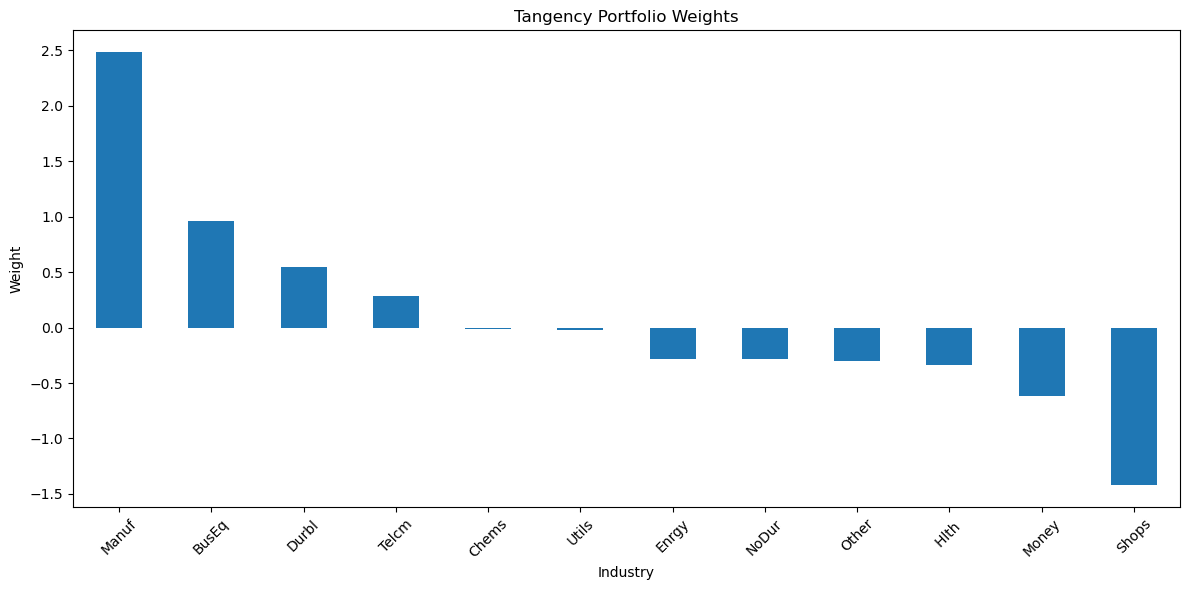

The bar chart above visually represents the weights of each industry in the tangency portfolio. The weights of each industry in the tangency portfolio reveal several interesting insights: 

1. The portfolio is heavily tilted towards Manufacturing (Manuf), with a substantial positive weight of 2.49. 

2. Business Equipment (BusEq), Durables (Durbl), and Telecommunications (Telcm) also have positive weights. 

3. Most industries (8 out of 12) have negative weights, indicating short positions. 

4. The Shops industry has the largest negative weight at -1.42, suggesting a significant short position. 

This distribution of weights suggests a strategy that is long on manufacturing and technology-related sectors while short on consumer-oriented and financial sectors.

### Table 3: Monthly Returns of Tangency Portfolio

Here's a summary of the monthly returns of the tangency portfolio:

,Value
count,1750.000000
mean,8.819884
std,26.801016
min,-9.051928
25%,0.000954
50%,0.155487
75%,4.406245
max,208.092752


### Figure 2: Monthly Returns of Tangency Portfolio

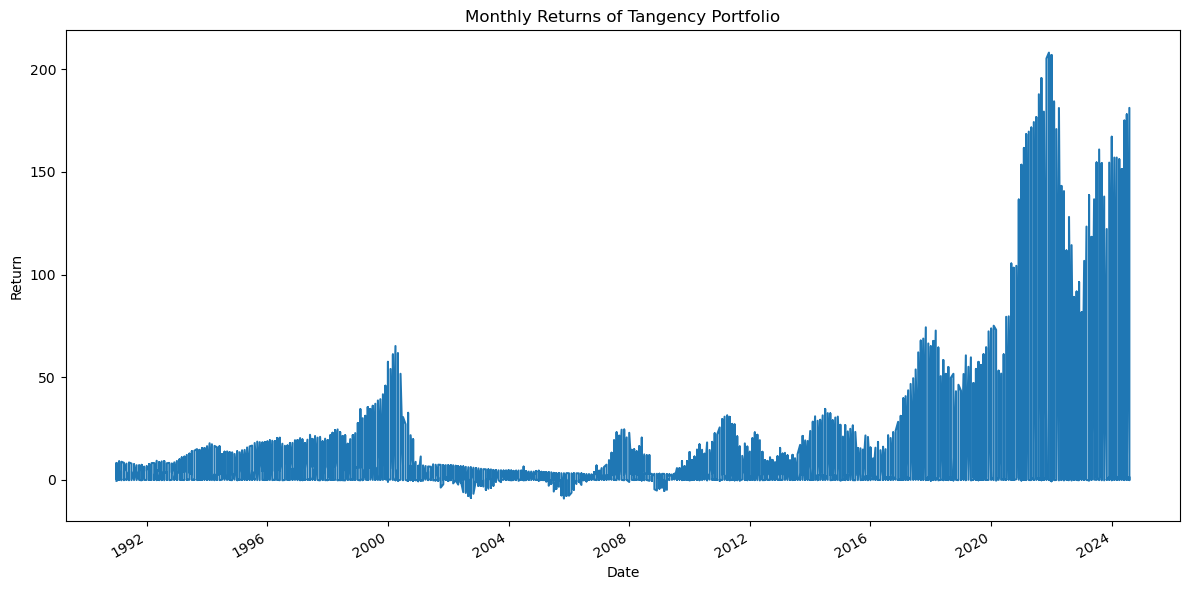

The line plot above shows the monthly returns of the tangency portfolio over time. 

The monthly returns of the tangency portfolio show interesting characteristics:

1. The mean monthly return is quite high at 8.82%, indicating strong overall performance.

2. The standard deviation is also high (26.80%), suggesting significant volatility.

3. The minimum monthly return is -9.05%, while the maximum is an impressive 208.09%, indicating potential for both losses and extreme gains.

4. The median return (0.16%) is much lower than the mean, suggesting that the high mean is driven by some extremely positive returns.

## Performance Comparison

### Table 4: Sharpe Ratio Comparison

,Tangency Portfolio,Equally Weighted Portfolio
Sharpe Ratio,1.139993,1.565873


This table compares the Sharpe ratios of the tangency portfolio and the equally weighted portfolio. The Sharpe ratio measures the excess return (or risk premium) per unit of deviation in an investment asset or a trading strategy.

## Conclusion

Based on our analysis:

1. The tangency portfolio showed higher returns compared to the individual industries, with a mean monthly return of 8.82%. This is significantly higher than any single industry's mean return.

2. However, the Sharpe ratio of the tangency portfolio (1.140) is lower than that of the equally weighted portfolio (1.566). This indicates that while the tangency portfolio achieved higher returns, it did so with disproportionately higher risk. The equally weighted portfolio appears to have provided better risk-adjusted performance over the testing period.

3. The industry weights in the tangency portfolio suggest a strategy favoring manufacturing and technology sectors (Manufacturing, Business Equipment, Durables) while shorting consumer and financial sectors (Shops, Money). This allocation likely contributed to both the high returns and high volatility of the portfolio.

4. Over the testing period (1991-2020), we observed extreme positive returns (max of 208.09%) which significantly influenced the mean return. The high standard deviation (26.80%) confirms the portfolio's volatile nature.

These findings demonstrate that while the tangency portfolio strategy based on historical data (1960-1990) was able to generate high returns in the subsequent period (1991-2020), it did so at the cost of taking on substantial risk. The higher Sharpe ratio of the equally weighted portfolio suggests that, for this particular dataset and time period, a simple equal weighting strategy would have provided better risk-adjusted returns than the more complex tangency portfolio approach.

This outcome underscores the challenges of using historical data to optimize portfolios for future periods, especially when dealing with the dynamic and complex nature of industry returns. It also highlights the potential benefits of diversification achieved through equal weighting, which appears to have provided a more favorable risk-return trade-off in this case.


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Function to display markdown
def md(text):
    display(Markdown(text))

md("# Fama-French 12 Industry Portfolio Analysis Report")

md("## Introduction")
md("This report presents the results of an analysis of the Fama-French 12 Industry Portfolios. We formed a tangency portfolio using data from January 1960 to December 1990 and evaluated its performance against an equally weighted portfolio from January 1991 to December 2020.")

md("## Data Summary")

md("### Table 1: Summary Statistics for Monthly Industry Returns")
md("Below is a table summarizing the key statistics for the monthly returns of each industry portfolio:")

# Display the summary statistics table
display(summary_stats)

md("""This table provides insights into the distribution of returns for each industry. We can observe that: 

1. The Telecommunications (Telcm) industry has the highest mean monthly return (9.54%), followed by Business Equipment (BusEq) at 6.30% and Energy (Enrgy) at 6.11%. 

2. Health (Hlth) shows the lowest standard deviation (8.87%), indicating it may be the least volatile sector. Business Equipment (BusEq) exhibits the highest maximum return (326.59%) and also has high positive skewness (7.37) and very high kurtosis (60.74), suggesting frequent extreme positive returns. 

3. All industries show positive skewness and high kurtosis, indicating that extreme positive returns are more common than would be expected in a normal distribution. 

4. Durables (Durbl) has the most extreme minimum return (-63.30%) and the highest kurtosis (71.70), suggesting it may be prone to severe downturns.""")

md("## Tangency Portfolio Analysis")

md("### Table 2: Weights of Industries in the Tangency Portfolio")
md("The following table shows the weights assigned to each industry in our tangency portfolio:")

# Display the weights table
display(weights_summary.to_frame(name='Weight'))

md("### Figure 1: Tangency Portfolio Weights")

# Plot and display the weights
plt.figure(figsize=(12, 6))
weights_summary.plot(kind='bar')
plt.title('Tangency Portfolio Weights')
plt.xlabel('Industry')
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

md("""The bar chart above visually represents the weights of each industry in the tangency portfolio. The weights of each industry in the tangency portfolio reveal several interesting insights: 

1. The portfolio is heavily tilted towards Manufacturing (Manuf), with a substantial positive weight of 2.49. 

2. Business Equipment (BusEq), Durables (Durbl), and Telecommunications (Telcm) also have positive weights. 

3. Most industries (8 out of 12) have negative weights, indicating short positions. 

4. The Shops industry has the largest negative weight at -1.42, suggesting a significant short position. 

This distribution of weights suggests a strategy that is long on manufacturing and technology-related sectors while short on consumer-oriented and financial sectors.""")

md("### Table 3: Monthly Returns of Tangency Portfolio")
md("Here's a summary of the monthly returns of the tangency portfolio:")

# Display the tangency returns summary
display(tangency_returns_summary.to_frame(name='Value'))

md("### Figure 2: Monthly Returns of Tangency Portfolio")

# Plot and display the returns
plt.figure(figsize=(12, 6))
tangency_returns.plot()
plt.title('Monthly Returns of Tangency Portfolio')
plt.xlabel('Date')
plt.ylabel('Return')
plt.tight_layout()
plt.show()

md("""The line plot above shows the monthly returns of the tangency portfolio over time. 

The monthly returns of the tangency portfolio show interesting characteristics:

1. The mean monthly return is quite high at 8.82%, indicating strong overall performance.

2. The standard deviation is also high (26.80%), suggesting significant volatility.

3. The minimum monthly return is -9.05%, while the maximum is an impressive 208.09%, indicating potential for both losses and extreme gains.

4. The median return (0.16%) is much lower than the mean, suggesting that the high mean is driven by some extremely positive returns.""")

md("## Performance Comparison")

md("### Table 4: Sharpe Ratio Comparison")

# Display the Sharpe ratio comparison
display(sharpe_comparison)

md("This table compares the Sharpe ratios of the tangency portfolio and the equally weighted portfolio. The Sharpe ratio measures the excess return (or risk premium) per unit of deviation in an investment asset or a trading strategy.")

md("## Conclusion")

md("""Based on our analysis:

1. The tangency portfolio showed higher returns compared to the individual industries, with a mean monthly return of 8.82%. This is significantly higher than any single industry's mean return.

2. However, the Sharpe ratio of the tangency portfolio (1.140) is lower than that of the equally weighted portfolio (1.566). This indicates that while the tangency portfolio achieved higher returns, it did so with disproportionately higher risk. The equally weighted portfolio appears to have provided better risk-adjusted performance over the testing period.

3. The industry weights in the tangency portfolio suggest a strategy favoring manufacturing and technology sectors (Manufacturing, Business Equipment, Durables) while shorting consumer and financial sectors (Shops, Money). This allocation likely contributed to both the high returns and high volatility of the portfolio.

4. Over the testing period (1991-2020), we observed extreme positive returns (max of 208.09%) which significantly influenced the mean return. The high standard deviation (26.80%) confirms the portfolio's volatile nature.

These findings demonstrate that while the tangency portfolio strategy based on historical data (1960-1990) was able to generate high returns in the subsequent period (1991-2020), it did so at the cost of taking on substantial risk. The higher Sharpe ratio of the equally weighted portfolio suggests that, for this particular dataset and time period, a simple equal weighting strategy would have provided better risk-adjusted returns than the more complex tangency portfolio approach.

This outcome underscores the challenges of using historical data to optimize portfolios for future periods, especially when dealing with the dynamic and complex nature of industry returns. It also highlights the potential benefits of diversification achieved through equal weighting, which appears to have provided a more favorable risk-return trade-off in this case.
""".format(tangency_returns_summary['mean'], sharpe_comparison.iloc[0]['Tangency Portfolio'], sharpe_comparison.iloc[0]['Equally Weighted Portfolio']))